Data shape: (1195, 24)


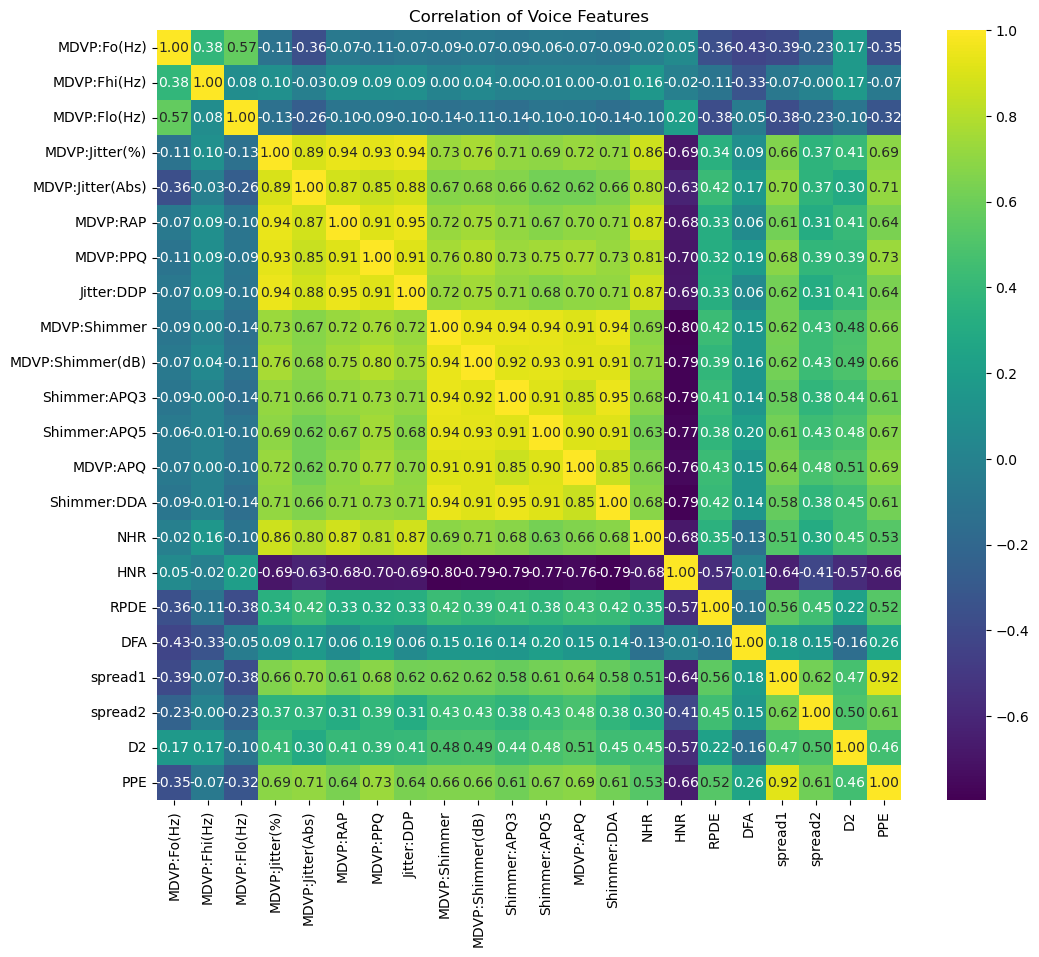

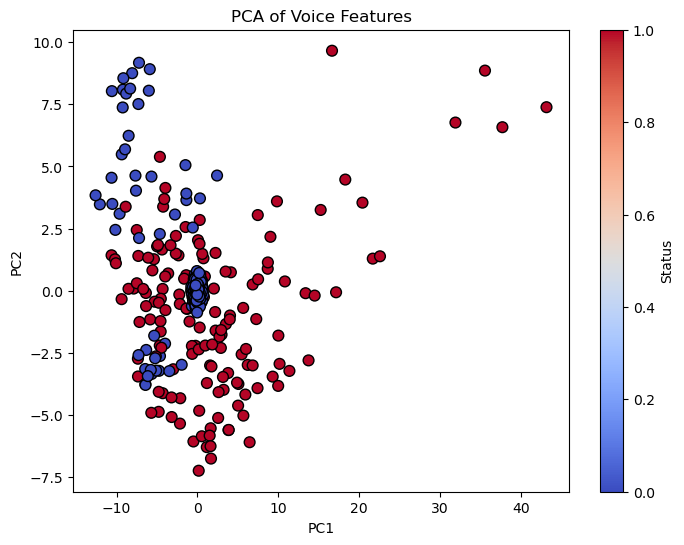

Logistic Regression Accuracy: 0.9096989966555183
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       265
           1       0.89      0.24      0.37        34

    accuracy                           0.91       299
   macro avg       0.90      0.62      0.66       299
weighted avg       0.91      0.91      0.89       299

Random Forest Accuracy: 0.9899665551839465
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       265
           1       0.92      1.00      0.96        34

    accuracy                           0.99       299
   macro avg       0.96      0.99      0.98       299
weighted avg       0.99      0.99      0.99       299



/var/folders/bx/hjvs221n4dd_8bq96qqz5kyw0000gn/T/ipykernel_1542/2103067416.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances[:15], y=feat_importances.index[:15], palette='viridis')


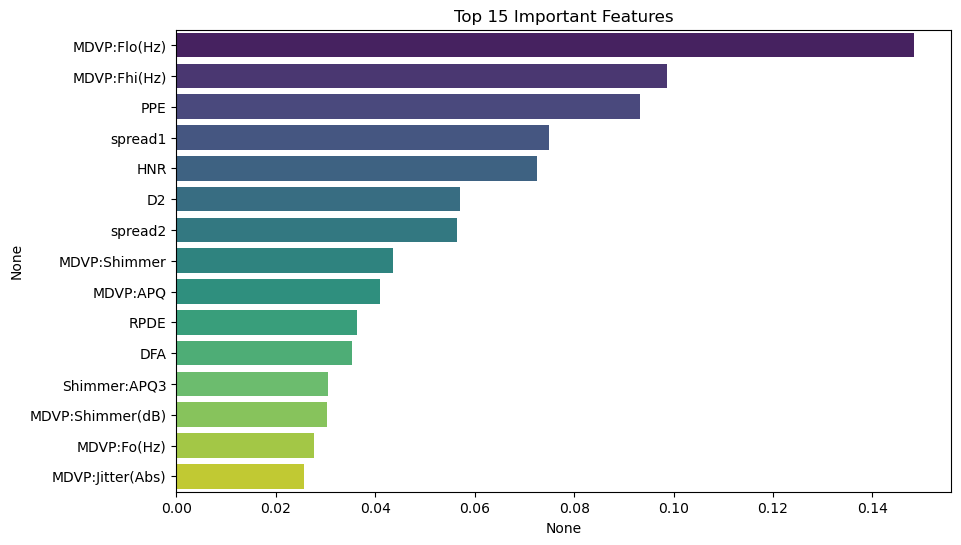

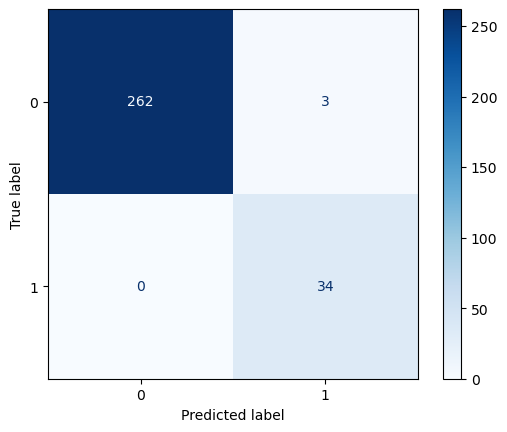

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# -------------------------------
# 1. Load Data
# -------------------------------
data = pd.read_csv("dataset_pr.csv")
print("Data shape:", data.shape)

# -------------------------------
# 2. Handle Missing Values
# -------------------------------
for col in data.columns:
    if data[col].dtype in ['float64', 'int64']:
        data[col] = data[col].fillna(data[col].mean())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

# -------------------------------
# 3. Features and Target
# -------------------------------
X = data.drop(columns=['name', 'status'])
y = data['status'].astype(int)

# -------------------------------
# 4. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap='viridis', annot=True, fmt=".2f")
plt.title("Correlation of Voice Features")
plt.show()

# -------------------------------
# 5. Standardize Features
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 6. PCA Visualization
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolor='k', s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Voice Features")
plt.colorbar(label='Status')
plt.show()

# -------------------------------
# 7. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# -------------------------------
# 8. Logistic Regression
# -------------------------------
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -------------------------------
# 9. Random Forest Classifier
# -------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))

# -------------------------------
# 10. Feature Importance
# -------------------------------
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances[:15], y=feat_importances.index[:15], palette='viridis')
plt.title("Top 15 Important Features")
plt.show()
# -------------------------------
# 11. Confusion Matrix Visualization
# -------------------------------
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')
plt.show()

